In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [10]:
data=pd.read_csv("C:/Users/allad/Downloads/WineQT.csv")
#data cleaning and analysis
data.head(10)
print(data.shape)
data.info()
data.isnull().sum()
print('duplicates',data.duplicated().sum())
#as data samples with quality 8 are less . so creating a new column in data
data["good_quality"] = (data["quality"] >= 7).astype(int)
print(data.head())

(1143, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
duplicates 0
   fixed acidity  volatile acidity  citric acid  re

In [16]:
#data splitting
X = data.drop(["quality", "good_quality", "Id"], axis=1)
y=data['good_quality']
x_train,x_test,y_train,y_test,=train_test_split(X,y,test_size=0.2,random_state=42)
#model creation
model=RandomForestClassifier(n_estimators=500,class_weight='balanced',random_state=42)
#model training
model.fit(x_train,y_train)
#model prediction
y_pred=model.predict(x_test)
#evalutaion
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy score',accuracy)
print('classification report\n',classification_report(y_test, y_pred))
#results
print("Wine Quality Classification Scale:")
print("0 = Not Good Wine (Original Quality Score: 3 to 6)")
print("1 = Good Wine (Original Quality Score: 7 to 8)")
print("-" * 50)
res=pd.DataFrame({'actual':y_test,'predicted':y_pred})
print(res.head(15))

Accuracy score 0.9388646288209607
classification report
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       201
           1       0.85      0.61      0.71        28

    accuracy                           0.94       229
   macro avg       0.90      0.80      0.84       229
weighted avg       0.94      0.94      0.93       229

Wine Quality Classification Scale:
0 = Not Good Wine (Original Quality Score: 3 to 6)
1 = Good Wine (Original Quality Score: 7 to 8)
--------------------------------------------------
      actual  predicted
158        0          0
1081       0          0
291        0          0
538        0          0
367        0          0
793        1          0
128        0          0
56         0          0
448        0          0
422        0          0
355        1          1
1134       0          0
774        0          0
777        0          0
1063       0          0


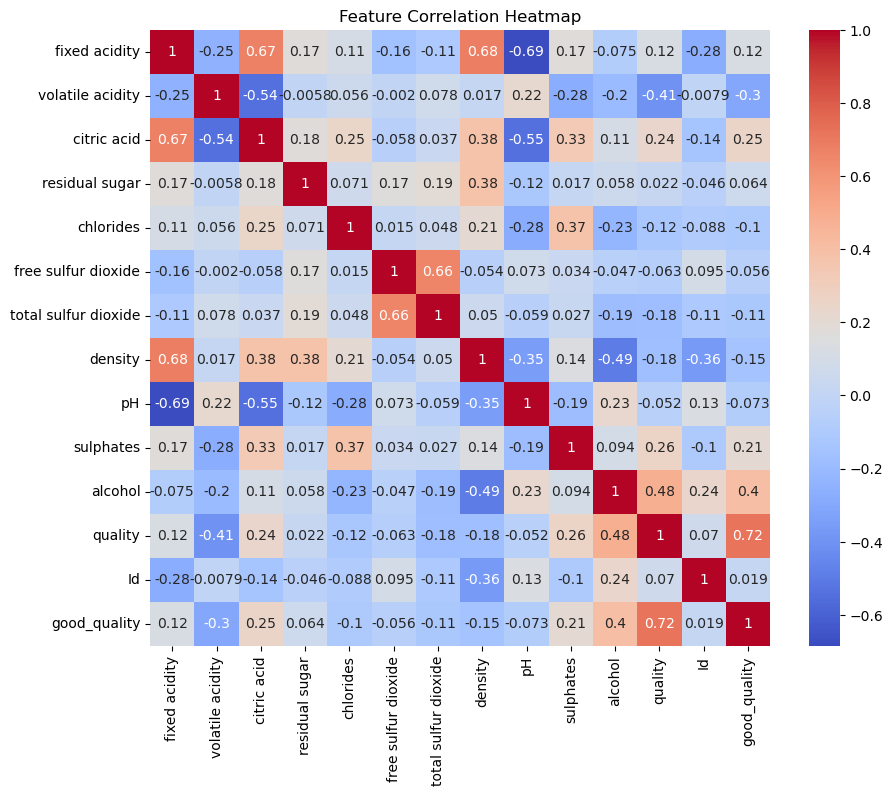

In [24]:
#visualization understanding of dataset
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

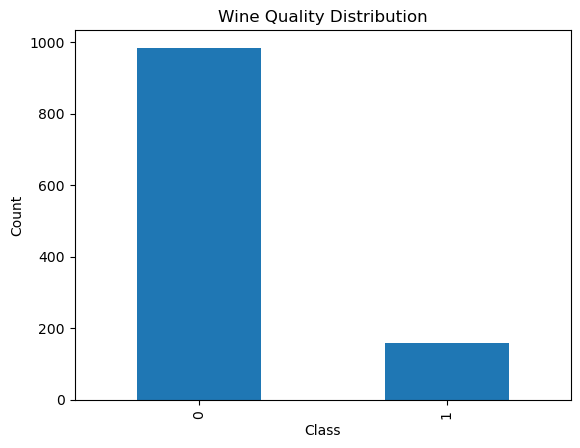

In [22]:
#wine quality visualization
data["good_quality"].value_counts().plot(kind="bar")
plt.title("Wine Quality Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()